# 0.0 Import DataSet

In [1]:
import math
import numpy as np
import pandas as pd
import random
import pickle
import warnings
import inflection
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from sklearn.ensemble      import RandomForestRegressor
from boruta                import BorutaPy
from sklearn.ensemble      import ExtraTreesClassifier
from matplotlib            import pyplot as plt

from sklearn import model_selection as ms
from sklearn import preprocessing   as pp
from sklearn import ensemble        as en
from sklearn import neighbors       as nh

In [2]:
df_train = pd.read_csv (r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Seguros\train.csv')
df_test = pd.read_csv (r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Seguros\test.csv')
df_sample_sub = pd.read_csv (r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Seguros\sample_submission.csv')

## 0.1 Helper Fuction


In [59]:
def cumulative_gain(y_true, y_proba):
    order = np.argsort(y_proba)[::-1]
    y_true = np.array(y_true)[order]
    plt.plot(np.arange(1,len(y_true)+1)/len(y_true), np.cumsum(y_true)/np.sum(y_true))
    plt.plot([0,1],[0,1],'--')
    plt.show()


def recall_at_k( data, k=15 ):
    data = data.reset_index( drop=True )
    data['ranking'] = data.index + 1
    
    data['recall_at_k'] = data['response'].cumsum() / data['response'].sum()
    
    return ( data.loc[ k, 'recall_at_k'], data )


def precision_at_k( data, k=10 ):
    data = data.reset_index( drop=True )
    data['ranking'] = data.index + 1
    
    data['precision_at_k'] = data['response'].cumsum() / data['ranking']
    
    return ( data.loc[ k, 'precision_at_k'], data )

# 1.0 Data Description

In [4]:
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
df1 = df_train.copy()

In [6]:
df1.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## 1.1 Data Types

In [7]:
df1.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

## 1.1 Data Dimensions

In [8]:
print( 'Number of Rows: {}'.format( df1.shape[0] ) )
print( 'Number of Cols: {}'.format( df1.shape[1] ) )

Number of Rows: 381109
Number of Cols: 12


## 1.1 Rename Columns

In [9]:
df1.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [10]:
cols_old = ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code','Previously_Insured', 'Vehicle_Age', 
            'Vehicle_Damage', 'Annual_Premium','Policy_Sales_Channel', 'Vintage', 'Response']

snakecase = lambda x: inflection.underscore(x)

cols_new = list(map( snakecase, cols_old ) )

#rename
df1.columns = cols_new

In [11]:
df1.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [12]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

In [13]:
num_attributes = df1.select_dtypes ( include=['int64', 'float64'] )
cat_attributes = df1.select_dtypes ( exclude=['int64', 'float64'] )

In [14]:
#Numerical Atributes
# Central Tendency- mean, meadina
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# dispersion- std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( min ) ).T
d3 = pd.DataFrame( num_attributes.apply( max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max()- x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# concatenar
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std','skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,9.443274e-16,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,6.725390e-01,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-2.159518e+01,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-1.152664e-01,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,1.677471e-01,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087e+00,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-9.000081e-01,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,3.029517e-03,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906e+00,3.298788


# 2.0 Feature Engginners

In [15]:
df2 = df1.copy()

In [16]:

# Vehicle Damage Number
df2['vehicle_damage'] = df2['vehicle_damage'].apply( lambda x: 1 if x == 'Yes' else 0 )

df2['vehicle_age'] = df2['vehicle_age'].apply( lambda x: 'over_2_years' if x == '> 2 Years' else 'between_1_2_year' if x == '1-2 Year' else 'below_1_year' )

In [17]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,1,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_year,0,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,1,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,below_1_year,0,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,below_1_year,0,27496.0,152.0,39,0


# 3.0 Data Filtering

In [18]:
df3 = df2.copy()

# 4.0 EDA ( Analise Exploratoria ) 

In [19]:
df4 = df3.copy()

In [20]:
df4.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='object')

## 4.1 Analise Univariavel

<Axes: xlabel='response', ylabel='age'>

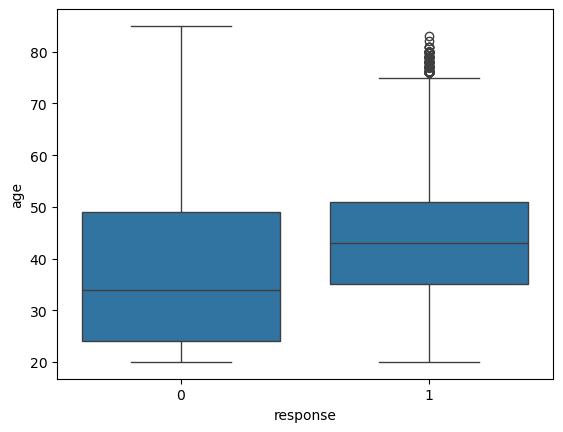

In [21]:
#age
sns.boxplot( x='response', y='age', data=df4 )

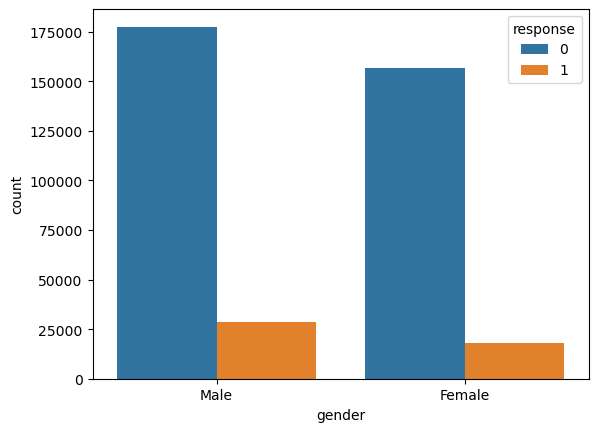

In [22]:
#gender
sns.countplot(data=df4, x='gender', hue='response')
plt.show()

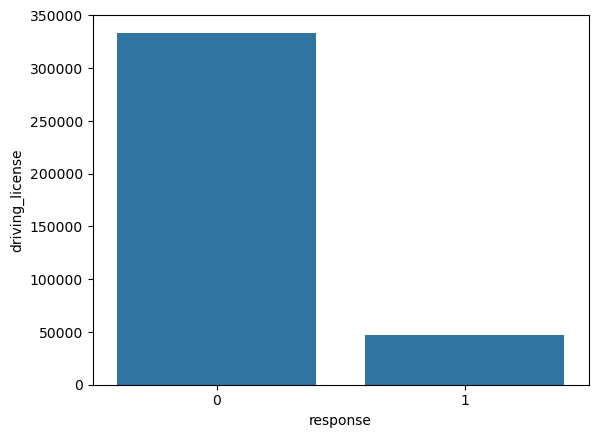

In [23]:
#DriveLincence
aux = df4[['driving_license','response']].groupby( 'response' ).sum().reset_index()
sns.barplot( data=aux, x='response', y='driving_license');

<Axes: xlabel='region_code', ylabel='id'>

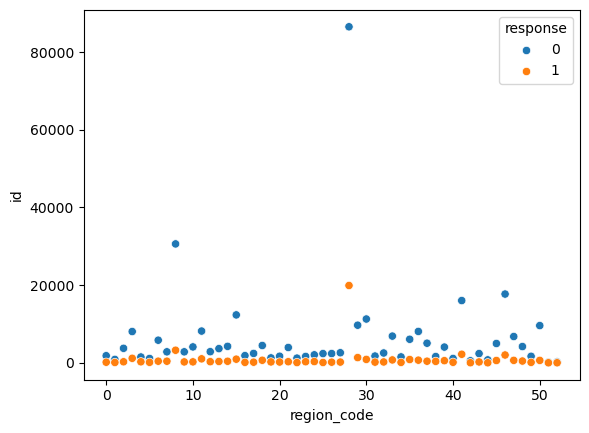

In [24]:
#region_code
aux0 = df4[['id','region_code','response']].groupby( ['region_code','response'] ).count().reset_index()
sns.scatterplot( x='region_code', y='id', hue='response', data=aux0 )

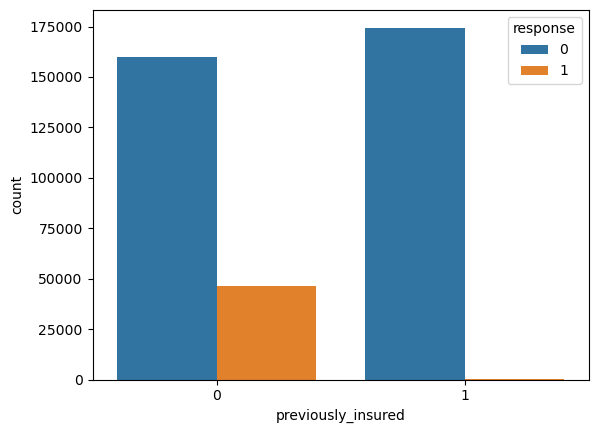

In [25]:
#previously_insured
sns.countplot(data=df4, x='previously_insured', hue='response')
plt.show()

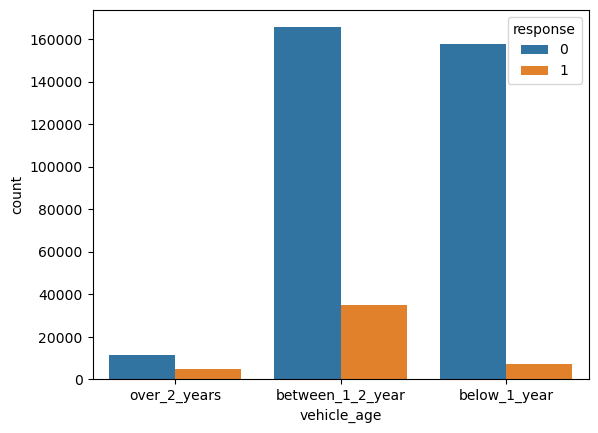

In [26]:
#vehicle_age
sns.countplot(data=df4, x='vehicle_age', hue='response')
plt.show()

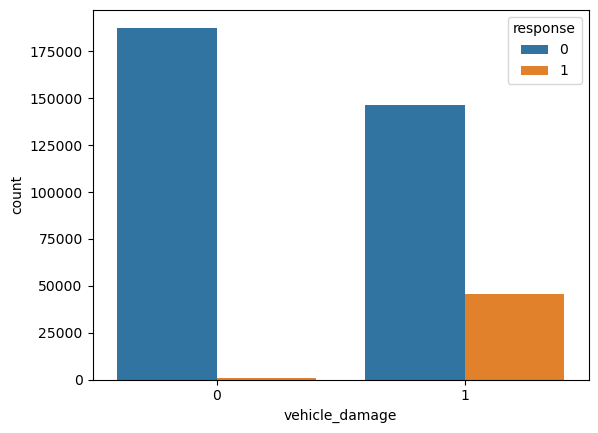

In [27]:
#vehicle_damage
sns.countplot(data=df4, x='vehicle_damage', hue='response')
plt.show()

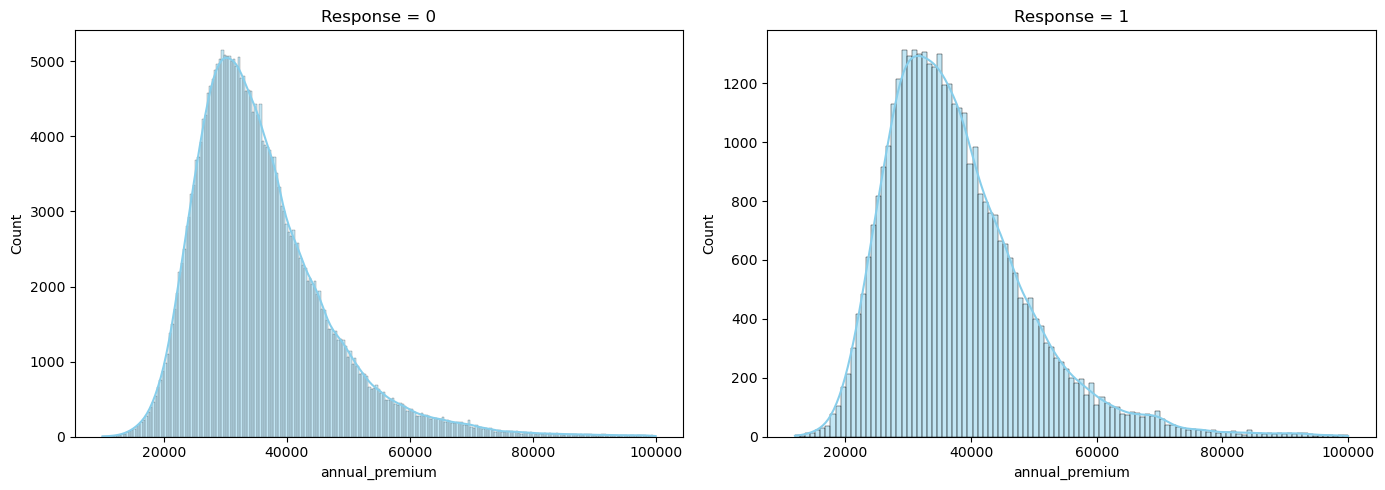

In [28]:
#annual_premium
# Filtrar dados
df4 = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 100000)]
aux0 = df4.loc[df4['response'] == 0, 'annual_premium']
aux1 = df4.loc[df4['response'] == 1, 'annual_premium']

# Criar figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

# response = 0
sns.histplot(aux0, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Response = 0')

# response = 1
sns.histplot(aux1, ax=axes[1], kde=True, color='skyblue')
axes[1].set_title('Response = 1')

plt.tight_layout()
plt.show()

## 4.2 Analise Multivariavel

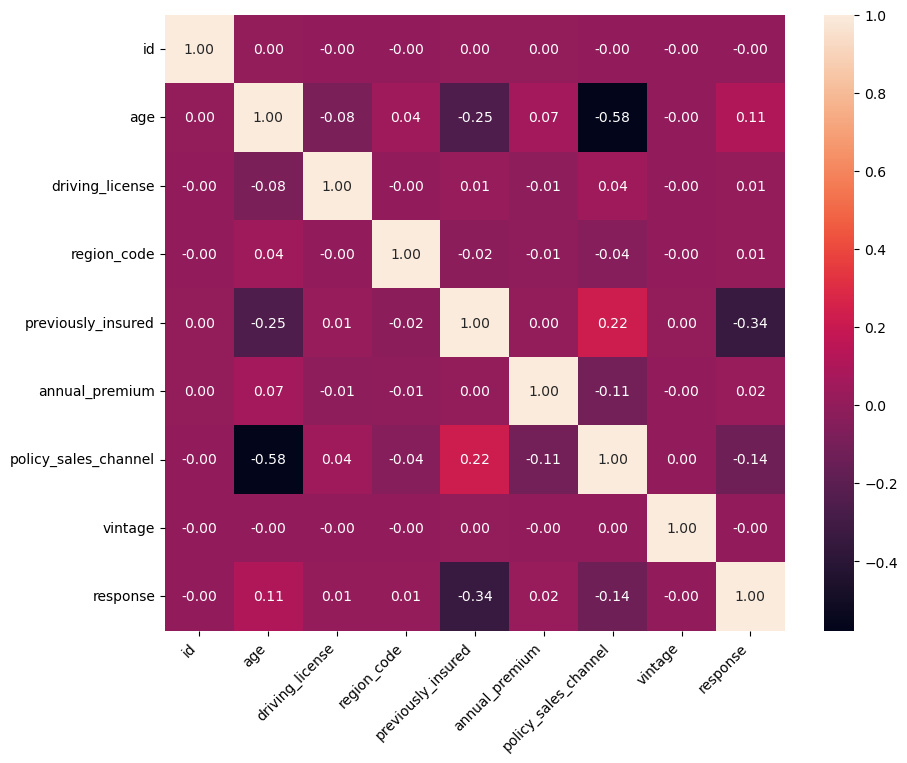

In [29]:
plt.figure(figsize=(10, 8))

correlation = num_attributes.corr(method='pearson')

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

# 5.0 Preparação dos Dados 

In [30]:
X = df4.drop('response', axis=1)
y = df4['response'].copy()

x_train, x_validation, y_train, y_validation = ms.train_test_split(X, y, test_size=0.20 )

df5 = pd.concat([x_train,y_train], axis=1)
df4.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,1,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_year,0,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,1,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,below_1_year,0,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,below_1_year,0,27496.0,152.0,39,0


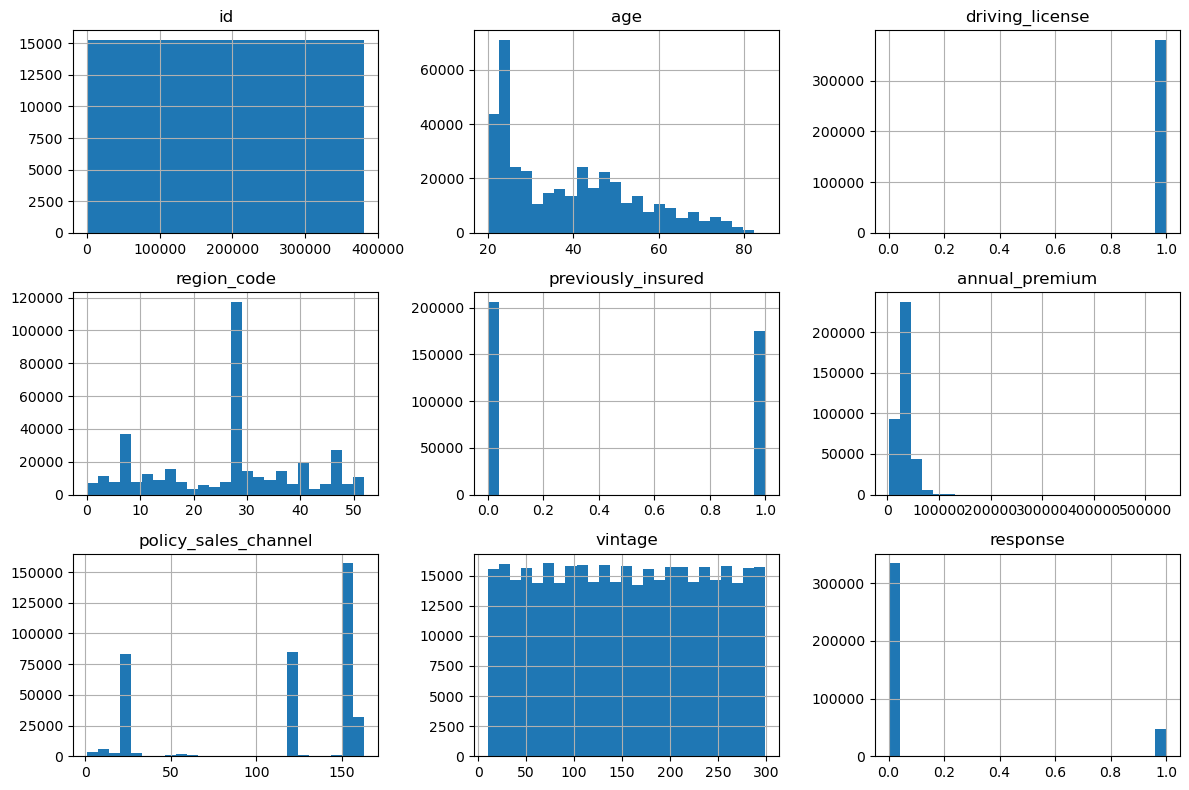

In [31]:
num_attributes.hist( bins= 25, figsize=(12,8), label='Histograma' );
plt.tight_layout()

## 5.1 Standardization

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
ss = StandardScaler() 
#annual_premium 
df5['annual_premium'] = ss.fit_transform(df5[['annual_premium']].values)
df5.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
9411,9412,Female,45,1,46.0,1,between_1_2_year,0,0.913492,26.0,216,0
126251,126252,Male,42,1,28.0,0,between_1_2_year,0,-0.474689,124.0,168,0
222671,222672,Female,32,1,8.0,1,below_1_year,0,0.476272,152.0,33,0
89121,89122,Male,27,1,28.0,1,below_1_year,0,0.933849,152.0,58,0
340295,340296,Male,66,1,47.0,0,over_2_years,1,0.360128,26.0,20,0


## 5.2 Rescaling

In [34]:
mms_age = pp.MinMaxScaler() 
mms_vintage = pp.MinMaxScaler()

#age
df5['age'] = mms_age.fit_transform( df5[['age']].values )

#vintage
df5['vintage'] = mms_vintage.fit_transform( df5[['vintage']].values )
df5.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
9411,9412,Female,0.384615,1,46.0,1,between_1_2_year,0,0.913492,26.0,0.712803,0
126251,126252,Male,0.338462,1,28.0,0,between_1_2_year,0,-0.474689,124.0,0.546713,0
222671,222672,Female,0.184615,1,8.0,1,below_1_year,0,0.476272,152.0,0.079585,0
89121,89122,Male,0.107692,1,28.0,1,below_1_year,0,0.933849,152.0,0.166090,0
340295,340296,Male,0.707692,1,47.0,0,over_2_years,1,0.360128,26.0,0.034602,0


## 5.3 Enconder 

In [35]:
#gender - Label Enconding
df5['gender'] = df5['gender'].apply( lambda x: 0 if x == 'Male' else 1 )

#region_code - Target Enconding
target_encode_region_code = df5.groupby('region_code')['response'].mean()
df5.loc[:,'region_code'] = df5['region_code'].map(target_encode_region_code)

#vehicle_age - One Hot Enconding
df5 = pd.get_dummies( df5, prefix='vehicle_age', columns=['vehicle_age'],dtype='int' )

#policy_sales_channel - Frequency
fe_policy_sales_channel = df5.groupby( 'policy_sales_channel' ).size() / len( df5)
df5.loc[:,'policy_sales_channel' ] = df5['policy_sales_channel'].map(fe_policy_sales_channel)

df5.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_damage,annual_premium,policy_sales_channel,vintage,response,vehicle_age_below_1_year,vehicle_age_between_1_2_year,vehicle_age_over_2_years
9411,9412,1,0.384615,1,0.097403,1,0,0.913492,0.213240,0.712803,0,0,1,0
126251,126252,0,0.338462,1,0.188311,0,0,-0.474689,0.195892,0.546713,0,0,1,0
222671,222672,1,0.184615,1,0.091000,1,0,0.476272,0.386382,0.079585,0,1,0,0
89121,89122,0,0.107692,1,0.188311,1,0,0.933849,0.386382,0.166090,0,1,0,0
340295,340296,0,0.707692,1,0.085644,0,1,0.360128,0.213240,0.034602,0,0,0,1


## 5.4 Validation Preparation

In [36]:
# gender
x_validation['gender'] = x_validation['gender'].apply( lambda x: 0 if x == 'Male' else 1 )

# age
x_validation.loc[:, 'age'] = mms_age.transform( x_validation[['age']].values )

# region_code
x_validation.loc[:, 'region_code'] = x_validation.loc[:, 'region_code'].map( target_encode_region_code )

# vehicle_age
x_validation = pd.get_dummies( x_validation, prefix='vehicle_age', columns=['vehicle_age'] )

# annual_premium
x_validation.loc[:, 'annual_premium'] = ss.transform( x_validation[['annual_premium']].values )

# policy_sales_channel
x_validation.loc[:, 'policy_sales_channel'] = x_validation['policy_sales_channel'].map( fe_policy_sales_channel )

# vintage
x_validation.loc[:, 'vintage'] = mms_vintage.transform( x_validation[['vintage']].values )

# fillna
x_validation = x_validation.fillna( 0 )

C:\Users\miks-\AppData\Local\Temp\ipykernel_25528\2325875661.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.61538462 0.10769231 0.18461538 ... 0.03076923 0.09230769 0.52307692]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_validation.loc[:, 'age'] = mms_age.transform( x_validation[['age']].values )
C:\Users\miks-\AppData\Local\Temp\ipykernel_25528\2325875661.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.20415225 0.24913495 0.816609   ... 0.62975779 0.41868512 0.7266436 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_validation.loc[:, 'vintage'] = mms_vintage.transform( x_validation[['vintage']].values )


# 6.0 Feature Selection

## 6.1 Feature Importancia

In [37]:
forest = en.ExtraTreesClassifier( n_estimators=250, random_state=0, n_jobs=-1)

#data preparation
x_train_n = df5.drop(['id','response'], axis=1)
y_train_n = y_train.values

#model
forest.fit( x_train_n, y_train_n )

ExtraTreesClassifier(n_estimators=250, n_jobs=-1, random_state=0)

Feature ranking:
                        feature  importance
0                annual_premium    0.273427
0                       vintage    0.247841
0                           age    0.155043
0                   region_code    0.103114
0                vehicle_damage    0.072779
0            previously_insured    0.058460
0          policy_sales_channel    0.058023
0      vehicle_age_below_1_year    0.015870
0  vehicle_age_between_1_2_year    0.006985
0                        gender    0.004748
0      vehicle_age_over_2_years    0.003152
0               driving_license    0.000559


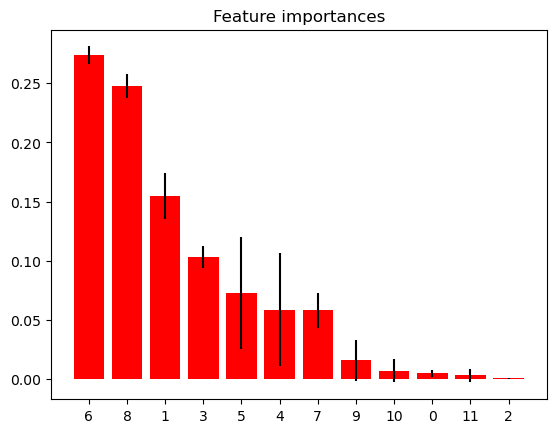

In [38]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")
df = pd.DataFrame()
for i, j in zip( x_train_n, forest.feature_importances_ ):
    aux = pd.DataFrame( {'feature': i, 'importance': j}, index=[0] )
    df = pd.concat( [df, aux], axis=0 )
    
print( df.sort_values( 'importance', ascending=False ) )


plt.figure()
plt.title("Feature importances")
plt.bar(range(x_train_n.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
plt.xticks(range(x_train_n.shape[1]), indices)
plt.xlim([-1, x_train_n.shape[1]])
plt.show()

## 6.2 Feature Subset

In [39]:
# training and test dataset for Boruta
x_train_n = df5.drop(['id','response'], axis=1 ).values
y_train_n = y_train.values.ravel()

# define RandomForestRegressor
et = en.ExtraTreesClassifier( n_jobs=-1 )

# define Boruta
boruta = BorutaPy( et, n_estimators='auto', verbose=0, random_state=42 ).fit(x_train_n, y_train_n )

In [40]:
cols_selected = boruta.support_.tolist()

# best features
x_train_fs = df5.drop( ['id', 'response'], axis=1 )
cols_selected_boruta = x_train_fs.iloc[:, cols_selected].columns.to_list()

# not selected boruta
cols_not_selected_boruta = list( np.setdiff1d( x_train_fs.columns, cols_selected_boruta ) )

In [41]:
cols_selected = ['annual_premium', 'vintage', 'age', 'region_code', 'vehicle_damage', 'previously_insured',
                 'policy_sales_channel']

# 7.0 Machine Learning Modelling

In [42]:
x_train = df5[cols_selected]

x_val = x_validation[ cols_selected ]
y_val = y_validation

## 7.1 KNN

In [43]:
# model definition
knn_model = nh.KNeighborsClassifier( n_neighbors=10 )

# model training
knn_model.fit( x_train, y_train )

# model prediction
yhat_knn = knn_model.predict_proba( x_val )

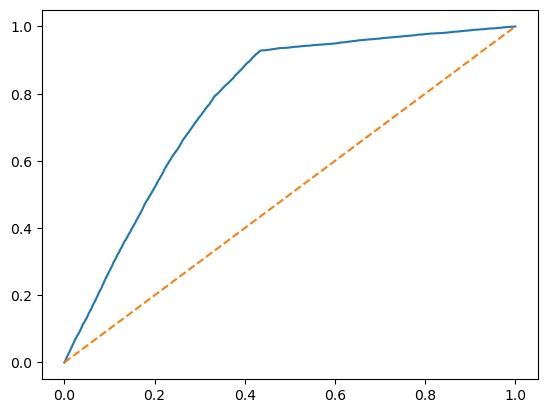

In [44]:
yhat_knn = knn_model.predict_proba( x_val )[:,1]
cumulative_gain(y_val, yhat_knn)

## 7.2 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn import linear_model    as lm

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
# model definition
lr_model = LogisticRegression( n_jobs=-1 )

# model training
lr_model.fit( x_train, y_train )

# model prediction
yhat_lr = lr_model.predict( x_val )

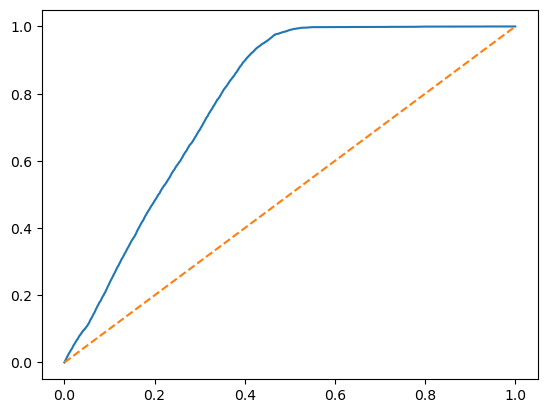

In [47]:
yhat_lr = lr_model.predict_proba( x_val )[:,1]
cumulative_gain(y_val, yhat_lr)

## 7.3 Extra Trees Classifier

In [48]:
from sklearn.ensemble import ExtraTreesClassifier

In [49]:
clf = ExtraTreesClassifier(n_estimators=100, random_state=0)

clf.fit( x_train, y_train )

yhat_clf = clf.predict_proba( x_val )

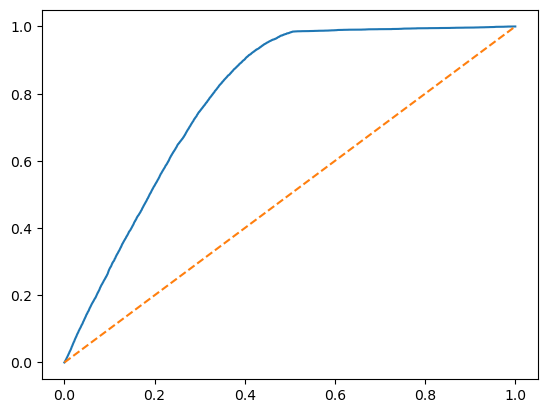

In [50]:
yhat_clf = clf.predict_proba( x_val )[:,1]
cumulative_gain(y_val, yhat_clf)

## 7.3 Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
rf = RandomForestClassifier(max_depth=2, random_state=0)

rf.fit( x_train, y_train )

yhay_rf = rf.predict_proba( x_val )

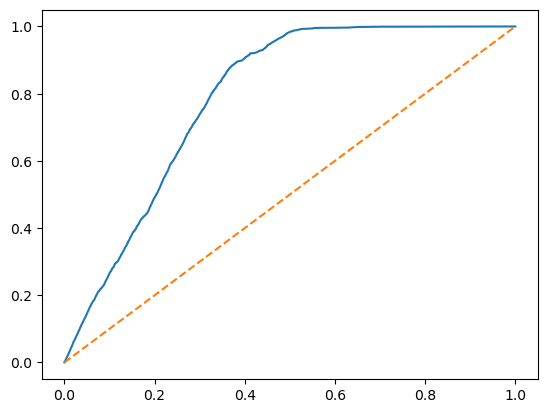

In [53]:
yhay_rf = rf.predict_proba( x_val )[:,1]
cumulative_gain(y_val, yhay_rf)

## 7.4 LGBM

In [54]:
from lightgbm import LGBMClassifier

In [55]:
model_lgbm = LGBMClassifier(
    n_estimators=100,  # número de árvores
    learning_rate=0.1, # taxa de aprendizado
    max_depth=-1,      # profundidade máxima das árvores (-1 = ilimitada)
    random_state=42,
    verbose=0
)

model_lgbm.fit( x_train, y_train )

yhay_lgbm = model_lgbm.predict_proba( x_val )

C:\Users\miks-\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\miks-\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\miks-\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\miks-\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^

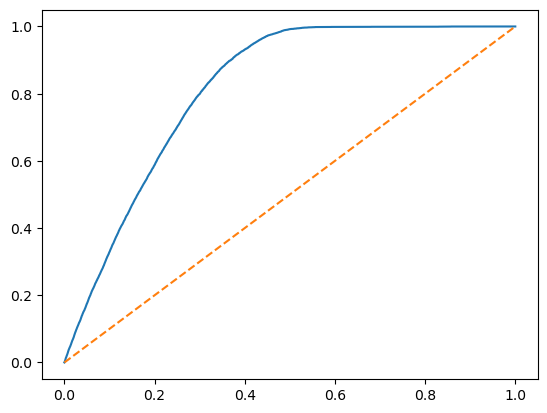

In [56]:
yhay_lgbm = model_lgbm.predict_proba( x_val )[:,1]
cumulative_gain(y_val, yhay_lgbm)

# 7.- Model Performance

## Metrics Performance

In [61]:
# copy dataframe
df8 = x_validation.copy()
df8['response'] = y_validation.copy()

# propensity score
df8['score'] = yhat_clf.tolist()

# sort clients by propensity score
df8 = df8.sort_values('score', ascending=False)

# compute precision at k 
clf_precision_at_20, data = precision_at_k(df8, k=20)
print('Precision at K: {}'.format(clf_precision_at_20))

# compute recall at k
clf_recall_at_15, data = recall_at_k(df8, k=15)
print('Recall at K: {}'.format(clf_recall_at_15))

Precision at K: 0.14285714285714285
Recall at K: 0.0002638522427440633


In [62]:
# copy dataframe
df8 = x_validation.copy()
df8['response'] = y_validation.copy()

# propensity score
df8['score'] = yhat_knn.tolist()

# sort clients by propensity score
df8 = df8.sort_values('score', ascending=False)

# compute precision at k 
precision_at_20, data = precision_at_k(df8, k=20)
print('Precision at K: {}'.format(precision_at_20))

# compute recall at k
recall_at_15, data = recall_at_k(df8, k=15)
print('Recall at K: {}'.format(recall_at_15))

Precision at K: 0.23809523809523808
Recall at K: 0.0005277044854881266


In [63]:
results = pd.DataFrame({
    'Model': ['Extra Tree', 'KNN'],
    'Precision': [clf_precision_at_20, precision_at_20],
    'Recall': [clf_recall_at_15, recall_at_15]
})

print(results)

        Model  Precision    Recall
0  Extra Tree   0.142857  0.000264
1         KNN   0.238095  0.000528


## Cummulative Curve Manually

In [ ]:
results = pd.DataFrame()
results['prediction'] = yhat_knn.tolist()
results['real'] = y_val.tolist()

# ordering by prediction
results = results.sort_values( 'prediction', ascending=False )

# Percentage of intereset ( Propensity Score )
results['real_cum'] = results['real'].cumsum() 
results['real_cum_perc'] = 100*results['real_cum']/results['real'].sum()

# Percentage of Base ( Clients )
results['base'] = range( 1, len( results ) + 1  )
results['base_cum_perc'] = 100*results['base']/len( results )

# Basline model
results['baseline'] = results['base_cum_perc']

plt.figure( figsize=(12,8))
sns.lineplot( x='base_cum_perc', y='real_cum_perc', data=results )
sns.lineplot( x='base_cum_perc', y='baseline', data=results )

## Lift Curve Manually

In [ ]:
results = pd.DataFrame()
results['prediction'] = yhat_knn.tolist()
results['real'] = y_val.tolist()

# ordering by prediction
results = results.sort_values( 'prediction', ascending=False )

# Percentage of intereset ( Propensity Score )
results['real_cum'] = results['real'].cumsum() 
results['real_cum_perc'] = 100*results['real_cum']/results['real'].sum()

# Percentage of Base ( Clients )
results['base'] = range( 1, len( results ) + 1  )
results['base_cum_perc'] = 100*results['base']/len( results )

# Basline model
results['baseline'] = results['base_cum_perc']

# Lift Calculation
results['lift'] = results['real_cum_perc'] / results['base_cum_perc']

plt.figure( figsize=(12,8))
sns.lineplot( x='base_cum_perc', y='lift', data=results )